<Figure size 1000x500 with 0 Axes>

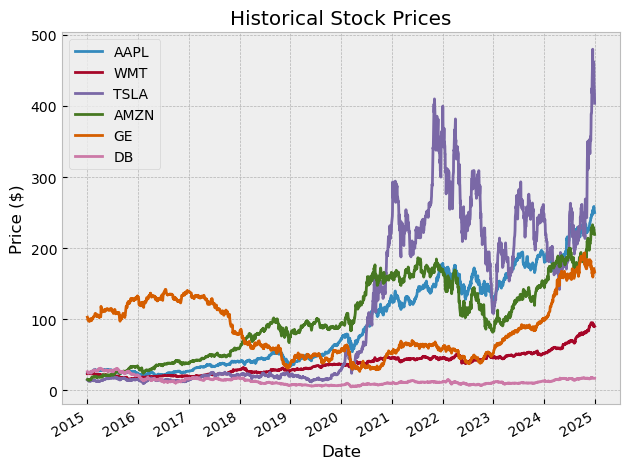

Annualized Returns:
AAPL    0.233536
WMT     0.135187
TSLA    0.332518
AMZN    0.266007
GE      0.048137
DB     -0.043833
dtype: float64

Annualized Covariance Matrix:
          AAPL       WMT      TSLA      AMZN        GE        DB
AAPL  0.081028  0.018664  0.068903  0.051761  0.033539  0.036788
WMT   0.018664  0.044619  0.019364  0.017503  0.012509  0.013176
TSLA  0.068903  0.019364  0.324960  0.073084  0.046771  0.055780
AMZN  0.051761  0.017503  0.073084  0.106664  0.029135  0.034851
GE    0.033539  0.012509  0.046771  0.029135  0.122610  0.060797
DB    0.036788  0.013176  0.055780  0.034851  0.060797  0.164211


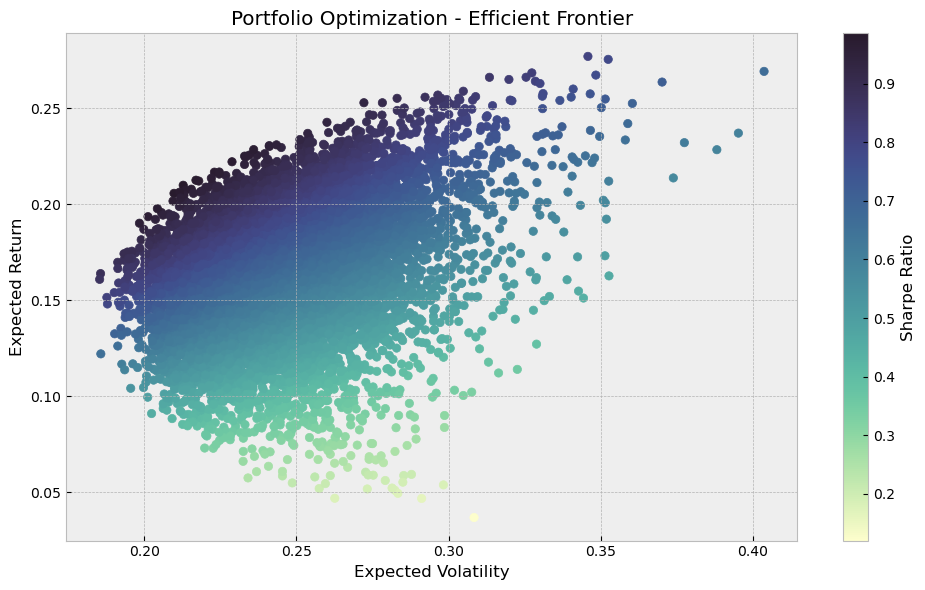

Optimal Portfolio Weights:
AAPL: 0.279
WMT: 0.376
TSLA: 0.070
AMZN: 0.275
GE: 0.000
DB: 0.000

Expected return: 0.2124
Expected volatility: 0.2104
Sharpe ratio: 1.0095


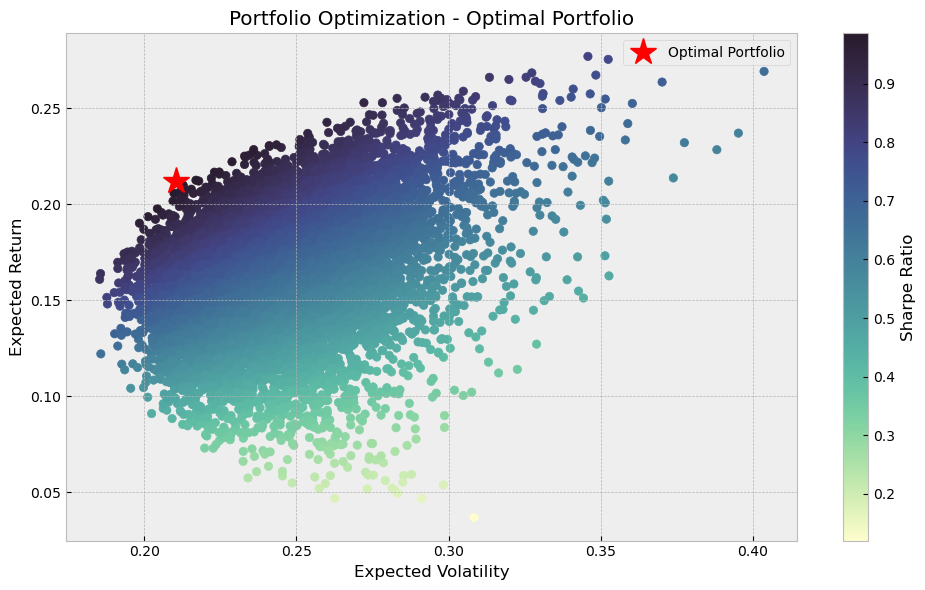

In [58]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as optim
import os
import cmocean.cm as cm  # Import cmocean for the balance colormap

# Set plotting style
plt.style.use("bmh")

# Constants
NUM_TRADING_DAYS = 252  # Standard number of trading days in a year
NUM_PORTFOLIOS = 10000  # Number of random portfolios to generate for simulation

# Portfolio assets
stocks = ['AAPL', 'WMT', 'TSLA', 'AMZN', 'GE', 'DB']  # Stocks in our portfolio
start_date = '2015-01-01'  # Historical data start date
end_date = '2025-01-01'    # Historical data end date

# Create directories for storing data and figures
os.makedirs('./data', exist_ok=True)
os.makedirs('./figs', exist_ok=True)

def download_data():
    """
    Download historical stock price data using yfinance API.
    
    Returns:
        pd.DataFrame: DataFrame containing closing prices for all stocks
    """
    stock_data = {}  # Dictionary to store stock price data
    for stock in stocks:
        ticker = yf.Ticker(stock) 
        # Get closing prices for the specified date range
        stock_data[stock] = ticker.history(start=start_date, end=end_date)['Close']
        
    # Convert to DataFrame for easier manipulation
    return pd.DataFrame(stock_data)

def show_data(data):
    """
    Visualize stock price data and save the figure.
    
    Args:
        data (pd.DataFrame): DataFrame containing stock price data
    """
    plt.figure(figsize=(10, 5))
    data.plot()
    plt.title('Historical Stock Prices')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.tight_layout()
    # Save figure to the figs directory
    plt.savefig('./figs/stock_prices.png', dpi=300)
    plt.show()

def calculate_return(data):
    """
    Calculate logarithmic daily returns from price data.
    
    Args:
        data (pd.DataFrame): DataFrame containing stock price data
        
    Returns:
        pd.DataFrame: DataFrame containing log returns (excluding first row)
    """
    # Use log returns for better statistical properties
    log_return = np.log(data/data.shift(1))
    
    # Exclude first row which contains NaN values
    return log_return[1:]

def show_statistics(returns):
    """
    Display annualized return and covariance statistics.
    
    Args:
        returns (pd.DataFrame): DataFrame containing daily returns
    """
    # Convert daily returns to annual returns
    annual_returns = returns.mean() * NUM_TRADING_DAYS
    annual_covariance = returns.cov() * NUM_TRADING_DAYS
    
    print("Annualized Returns:")
    print(annual_returns)
    print("\nAnnualized Covariance Matrix:")
    print(annual_covariance)
    
    # Save statistics to CSV files
    annual_returns.to_csv('./data/annual_returns.csv')
    annual_covariance.to_csv('./data/annual_covariance.csv')
    
def show_mean_variance(returns, weights):
    """
    Calculate and display the expected return and volatility for a specific portfolio.
    
    Args:
        returns (pd.DataFrame): DataFrame containing daily returns
        weights (np.array): Array of portfolio weights
    """
    # Calculate annualized portfolio return
    portfolio_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    
    # Calculate annualized portfolio volatility
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * NUM_TRADING_DAYS, weights)))
    
    print("Expected portfolio mean (return): ", portfolio_return)
    print("Expected portfolio volatility (std): ", portfolio_volatility)
    
    # Save the portfolio metrics
    pd.DataFrame({
        'Metric': ['Return', 'Volatility', 'Sharpe Ratio'],
        'Value': [portfolio_return, portfolio_volatility, portfolio_return/portfolio_volatility]
    }).to_csv('./data/specific_portfolio_metrics.csv', index=False)

def generate_portfolios(returns):
    """
    Generate random portfolios with varying weights.
    
    Args:
        returns (pd.DataFrame): DataFrame containing daily returns
        
    Returns:
        tuple: Arrays of portfolio weights, expected returns, and expected risks
    """
    portfolio_means = []
    portfolio_risks = []
    portfolio_weights = []
    
    # Generate random portfolios
    for _ in range(NUM_PORTFOLIOS):
        # Generate random weights
        w = np.random.random(len(stocks))
        # Normalize weights to sum to 1
        w /= np.sum(w)
        
        # Store portfolio weights
        portfolio_weights.append(w)
        
        # Calculate annualized return
        portfolio_means.append(np.sum(returns.mean() * w) * NUM_TRADING_DAYS)
        
        # Calculate annualized volatility
        portfolio_risks.append(np.sqrt(np.dot(w.T, np.dot(returns.cov() * NUM_TRADING_DAYS, w))))
    
    # Save generated portfolio data
    portfolio_data = pd.DataFrame({
        'Return': portfolio_means,
        'Risk': portfolio_risks
    })
    portfolio_data.to_csv('./data/generated_portfolios.csv', index=False)
        
    return np.array(portfolio_weights), np.array(portfolio_means), np.array(portfolio_risks)

def show_portfolios(returns, volatilities):
    """
    Visualize the efficient frontier with random portfolios colored by Sharpe ratio.
    
    Args:
        returns (np.array): Array of expected returns
        volatilities (np.array): Array of expected volatilities
    """
    # Calculate Sharpe ratios (assuming risk-free rate = 0)
    sharpe_ratios = returns / volatilities
    
    plt.figure(figsize=(10, 6))
    
    # Create scatter plot with cmocean's balance colormap
    sc = plt.scatter(volatilities, returns, c=sharpe_ratios, marker='o', cmap=cm.deep)
    
    plt.xlabel("Expected Volatility")
    plt.ylabel("Expected Return")
    cbar = plt.colorbar(sc, label="Sharpe Ratio")
    plt.title("Portfolio Optimization - Efficient Frontier")
    plt.tight_layout()
    
    # Save figure
    plt.savefig('./figs/efficient_frontier.png', dpi=300)
    plt.show()

def statistics(weights, returns):
    """
    Calculate portfolio statistics (return, volatility, Sharpe ratio).
    
    Args:
        weights (np.array): Portfolio weights
        returns (pd.DataFrame): DataFrame containing daily returns
        
    Returns:
        np.array: Array containing [return, volatility, Sharpe ratio]
    """
    # Calculate annualized return
    portfolio_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    
    # Calculate annualized volatility
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * NUM_TRADING_DAYS, weights)))
    
    # Calculate Sharpe ratio (assuming risk-free rate = 0)
    sharpe_ratio = portfolio_return / portfolio_volatility
    
    return np.array([portfolio_return, portfolio_volatility, sharpe_ratio])

def min_function_sharpe(weights, returns):
    """
    Objective function for optimization (negative Sharpe ratio).
    
    Args:
        weights (np.array): Portfolio weights
        returns (pd.DataFrame): DataFrame containing daily returns
        
    Returns:
        float: Negative Sharpe ratio (for minimization)
    """
    # Maximize Sharpe ratio by minimizing its negative
    return -statistics(weights, returns)[2]

def optimize_portfolios(weights, returns):
    """
    Find the optimal portfolio weights using SciPy's optimization.
    
    Args:
        weights (np.array): Initial weights to start optimization
        returns (pd.DataFrame): DataFrame containing daily returns
        
    Returns:
        OptimizeResult: Optimization result object
    """
    # Constraint: sum of weights = 1
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    
    # Bounds: each weight between 0 and 1
    bounds = tuple((0, 1) for _ in range(len(stocks)))
    
    # Use Sequential Least Squares Programming (SLSQP) method
    return optim.minimize(
        fun=min_function_sharpe, 
        x0=weights[0],  # Initial weights
        args=returns,
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints
    )

def print_optimal_portfolio(optimum, returns):
    """
    Display and save the optimal portfolio details.
    
    Args:
        optimum (OptimizeResult): Optimization result
        returns (pd.DataFrame): DataFrame containing daily returns
    """
    # Round optimal weights for better readability
    opt_weights = optimum['x'].round(3)
    
    # Calculate statistics for the optimal portfolio
    stats = statistics(opt_weights, returns)
    
    print("Optimal Portfolio Weights:")
    for stock, weight in zip(stocks, opt_weights):
        print(f"{stock}: {weight:.3f}")
    
    print('\nExpected return: {:.4f}'.format(stats[0]))
    print('Expected volatility: {:.4f}'.format(stats[1]))
    print('Sharpe ratio: {:.4f}'.format(stats[2]))
    
    # Save optimal portfolio data
    optimal_data = pd.DataFrame({
        'Stock': stocks,
        'Weight': opt_weights
    })
    optimal_data.to_csv('./data/optimal_portfolio.csv', index=False)
    
    # Save optimal portfolio statistics
    pd.DataFrame({
        'Metric': ['Return', 'Volatility', 'Sharpe Ratio'],
        'Value': stats
    }).to_csv('./data/optimal_portfolio_metrics.csv', index=False)

def show_optimal_portfolio(opt, rets, portfolio_rets, portfolio_vols):
    """
    Visualize the efficient frontier and highlight the optimal portfolio.
    
    Args:
        opt (OptimizeResult): Optimization result
        rets (pd.DataFrame): DataFrame containing daily returns
        portfolio_rets (np.array): Array of portfolio returns
        portfolio_vols (np.array): Array of portfolio volatilities
    """
    # Calculate Sharpe ratios
    sharpe_ratios = portfolio_rets / portfolio_vols
    
    # Calculate statistics for the optimal portfolio
    opt_stats = statistics(opt['x'], rets)
    
    plt.figure(figsize=(10, 6))
    
    # Create scatter plot with cmocean's balance colormap
    sc = plt.scatter(portfolio_vols, portfolio_rets, c=sharpe_ratios, marker='o', cmap=cm.deep)
    
    # Highlight the optimal portfolio
    plt.plot(opt_stats[1], opt_stats[0], 'r*', markersize=20.0, label='Optimal Portfolio')
    
    plt.xlabel("Expected Volatility")
    plt.ylabel("Expected Return")
    cbar = plt.colorbar(sc, label="Sharpe Ratio")
    plt.title("Portfolio Optimization - Optimal Portfolio")
    plt.legend()
    plt.tight_layout()
    
    # Save figure
    plt.savefig('./figs/optimal_portfolio.png', dpi=300)
    plt.show()


if __name__ == '__main__':
    # Download and save historical stock data
    dataset = download_data()
    dataset.to_csv('./data/stock_price_data.csv')
    
    # Visualize stock price data
    show_data(dataset)
    
    # Calculate daily returns
    log_daily_returns = calculate_return(dataset) 
    log_daily_returns.to_csv('./data/daily_returns.csv')
    
    # Display and save statistics
    show_statistics(log_daily_returns)
    
    # Generate random portfolios
    pweights, means, risks = generate_portfolios(log_daily_returns)
    
    # Visualize efficient frontier
    show_portfolios(means, risks)
    
    # Find optimal portfolio
    optimum = optimize_portfolios(pweights, log_daily_returns)
    
    # Display and save optimal portfolio details
    print_optimal_portfolio(optimum, log_daily_returns)
    
    # Visualize optimal portfolio on efficient frontier
    show_optimal_portfolio(optimum, log_daily_returns, means, risks)